# NumCompute-Stream Quickstart



This notebook shows:

- package import checks
- streaming preprocessing + model training
- per-chunk logging through `StreamTrainer`
- model comparison between a single tree and a random forest
- visualisation outputs
- benchmark hooks



## Rubric alignment

- **Algorithm design:** incremental `.partial_fit()` flow, chunk-based training, and tree / ensemble reuse.
- **Functionality:** runnable pipeline, streaming logs, predictions, and plots.
- **Code reusability:** modular imports from the package; the same code paths used in scripts and notebooks.
- **Maintainability:** compact, readable steps with clear section headers.
- **Testing evidence:** includes a smoke test section and verification calls.
- **Style and documentation:** all steps are explained in plain language.


In [1]:
# Run this notebook from the project root so `numcompute` is importable.
# Example layout:
#   numcompute-individual/
#   ├── numcompute/
#   ├── tests/
#   ├── benchmark/
#   └── demo/

from pathlib import Path
import sys
import json

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: c:\Users\Aakash\Downloads\Documents\Adelaide University\Semester 1\Programming in AI\numcompute individual


In [2]:
import sys
from pathlib import Path
import numpy as np

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "numcompute").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numcompute as nc

from numcompute.io import load_csv
from numcompute.preprocessing import StandardScaler, MinMaxScaler, SimpleImputer, OneHotEncoder
from numcompute.sort_search import sort_array, lexsort_rows, multi_key_sort, topk, top_k, quickselect, binary_search
from numcompute.rank import rank, percentile
from numcompute.stats import mean, median, std, min as stats_min, max as stats_max, histogram, quantile, StreamingStats
from numcompute.metrics import accuracy, precision, recall, f1, confusion_matrix, mse, roc_curve, auc, StreamingAccuracy
from numcompute.optim import grad, jacobian
from numcompute.pipeline import Pipeline, FeatureUnion
from numcompute.tree import DecisionTreeClassifier
from numcompute.ensemble import BaggingClassifier, RandomForestClassifier
from numcompute.stream import StreamTrainer, iter_chunks
from numcompute.visualise import plot_metric_over_time, compare_models, plot_predictions_vs_ground_truth
from numcompute.benchmarking import (
    benchmark_function,
    compare_functions,
    format_benchmark_table,
    vectorized_sum_of_squares,
    loop_sum_of_squares,
    benchmark_streaming_pipeline,
)

ImportError: cannot import name 'sort_array' from 'numcompute.sort_search' (c:\Users\Aakash\Downloads\Documents\Adelaide University\Semester 1\Programming in AI\numcompute individual\numcompute\sort_search.py)

## Import smoke test

This verifies the package surface used by the demo and benchmark scripts.


In [2]:
import numpy as np

from numcompute import (
    StandardScaler,
    MinMaxScaler,
    SimpleImputer,
    OneHotEncoder,
    DecisionTreeClassifier,
    RandomForestClassifier,
    Pipeline,
    StreamTrainer,
    iter_chunks,
    benchmark_streaming_pipeline,
)

print("Imports OK")


Imports OK


## Synthetic streaming dataset

The assignment emphasises real-time adaptation to incoming chunks, so we create a dataset with mild drift across samples.


In [3]:
def make_stream_data(seed: int = 7, n_samples: int = 320, n_features: int = 5):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n_samples, n_features))
    drift = np.linspace(-0.6, 0.6, n_samples)
    score = (
        1.4 * X[:, 0]
        - 1.0 * X[:, 1]
        + 0.7 * X[:, 2]
        + 0.15 * np.sin(np.linspace(0, 6 * np.pi, n_samples))
        + drift
        + 0.3 * rng.normal(size=n_samples)
    )
    y = (score > 0).astype(int)
    return X, y

X, y = make_stream_data()
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class balance:", np.bincount(y))


X shape: (320, 5)
y shape: (320,)
Class balance: [182 138]


## Build two streaming pipelines

We compare a **single decision tree** and a **random forest**. Both are wrapped in the same `Pipeline` structure so they share the same streaming workflow.


In [4]:
def build_pipeline(model):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", model),
    ])

tree_pipeline = build_pipeline(
    DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=2,
        max_features="sqrt",
        random_state=42,
    )
)

forest_pipeline = build_pipeline(
    RandomForestClassifier(
        n_estimators=7,
        max_depth=4,
        min_samples_split=2,
        max_features="sqrt",
        random_state=42,
    )
)

print("Pipelines ready")


Pipelines ready


## Streaming run

The trainer updates on each chunk and records chunk accuracy, cumulative accuracy, and memory footprint.


In [5]:
def run_streaming_experiment(pipeline, X, y, chunk_size=32):
    trainer = StreamTrainer(pipeline=pipeline)
    chunk_logs = []

    for X_chunk, y_chunk in iter_chunks(X, y, chunk_size=chunk_size):
        trainer.fit_chunk(X_chunk, y_chunk)
        chunk_logs.append(trainer.score_chunk(X_chunk, y_chunk))

    return trainer, chunk_logs

tree_trainer, tree_logs = run_streaming_experiment(tree_pipeline, X, y, chunk_size=32)
forest_trainer, forest_logs = run_streaming_experiment(forest_pipeline, X, y, chunk_size=32)

print("Tree final accuracy:", round(tree_trainer.result(), 4))
print("Forest final accuracy:", round(forest_trainer.result(), 4))
print("Chunks processed:", len(tree_logs))


Tree final accuracy: 0.9156
Forest final accuracy: 0.9313
Chunks processed: 10


## Inspect the logs

These tables are useful for the demo video and for validating the streaming behaviour.


In [6]:
def show_log_preview(logs, name, n=5):
    print(f"--- {name} log preview ---")
    for row in logs[:n]:
        print(row)
    if len(logs) > n:
        print("...")
        print(logs[-1])

show_log_preview(tree_logs, "Tree")
show_log_preview(forest_logs, "Forest")


--- Tree log preview ---
{'chunk_index': 1, 'chunk_size': 32, 'chunk_accuracy': 1.0, 'cumulative_accuracy': 1.0, 'memory_bytes': 1408}
{'chunk_index': 2, 'chunk_size': 32, 'chunk_accuracy': 0.96875, 'cumulative_accuracy': 0.984375, 'memory_bytes': 1408}
{'chunk_index': 3, 'chunk_size': 32, 'chunk_accuracy': 1.0, 'cumulative_accuracy': 0.9895833333333334, 'memory_bytes': 1408}
{'chunk_index': 4, 'chunk_size': 32, 'chunk_accuracy': 0.75, 'cumulative_accuracy': 0.9296875, 'memory_bytes': 1408}
{'chunk_index': 5, 'chunk_size': 32, 'chunk_accuracy': 0.84375, 'cumulative_accuracy': 0.9125, 'memory_bytes': 1408}
...
{'chunk_index': 10, 'chunk_size': 32, 'chunk_accuracy': 0.875, 'cumulative_accuracy': 0.915625, 'memory_bytes': 1408}
--- Forest log preview ---
{'chunk_index': 1, 'chunk_size': 32, 'chunk_accuracy': 1.0, 'cumulative_accuracy': 1.0, 'memory_bytes': 1408}
{'chunk_index': 2, 'chunk_size': 32, 'chunk_accuracy': 0.96875, 'cumulative_accuracy': 0.984375, 'memory_bytes': 1408}
{'chunk_i

## Visualisation

The assignment requires reusable plotting utilities that can be used in notebooks, scripts, and reports.


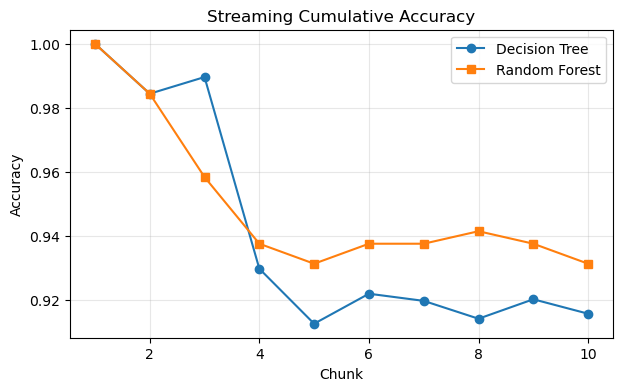

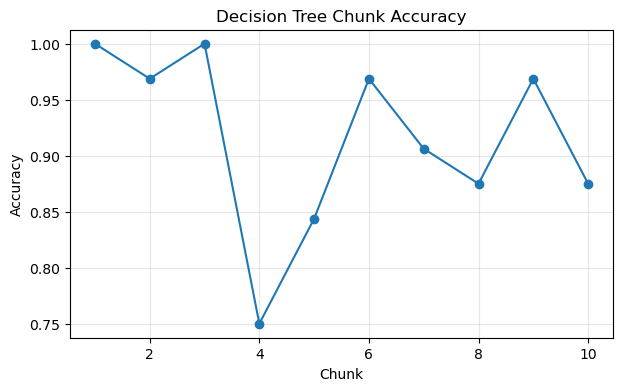

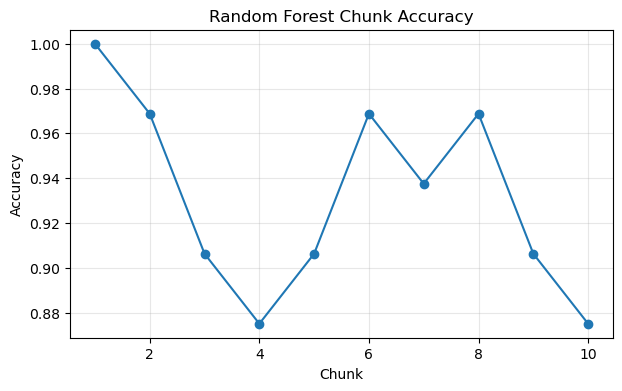

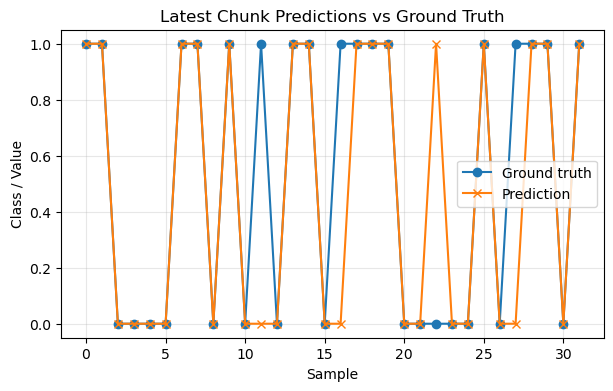

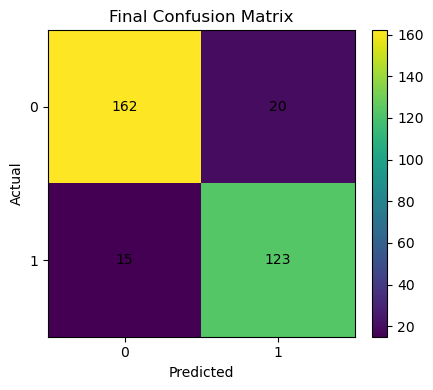

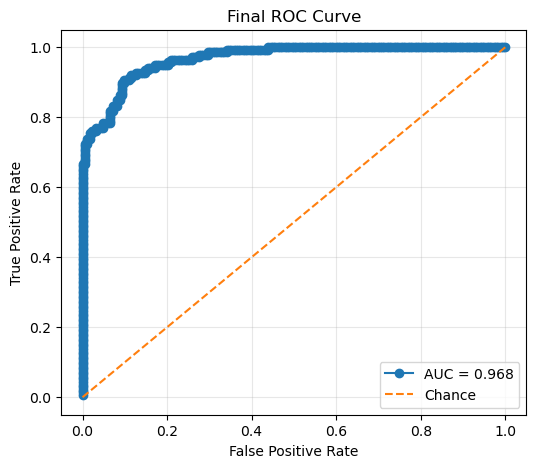

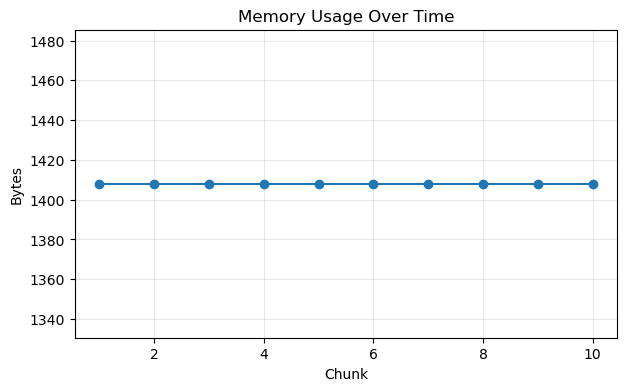

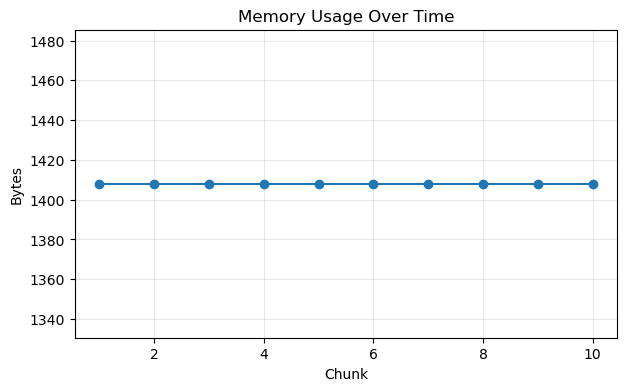

In [7]:
from numcompute.visualise import (
    compare_models,
    plot_metric_over_time,
    plot_predictions_vs_ground_truth,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_memory_usage,
)

# Extract metrics from streaming history
tree_chunk_acc = [row["chunk_accuracy"] for row in tree_logs]
forest_chunk_acc = [row["chunk_accuracy"] for row in forest_logs]

tree_cum_acc = [row["cumulative_accuracy"] for row in tree_logs]
forest_cum_acc = [row["cumulative_accuracy"] for row in forest_logs]

forest_memory = [row["memory_bytes"] for row in forest_logs]

# Compare cumulative accuracy
compare_models(
    tree_cum_acc,
    forest_cum_acc,
    labels=("Decision Tree", "Random Forest"),
    title="Streaming Cumulative Accuracy",
    ylabel="Accuracy",
    show=True,
)

# Per-chunk accuracy plots
plot_metric_over_time(
    tree_chunk_acc,
    title="Decision Tree Chunk Accuracy",
    ylabel="Accuracy",
    show=True,
)

plot_metric_over_time(
    forest_chunk_acc,
    title="Random Forest Chunk Accuracy",
    ylabel="Accuracy",
    show=True,
)

# Latest chunk predictions
last_X, last_y = list(iter_chunks(X, y, chunk_size=32))[-1]
last_pred = forest_trainer.predict(last_X)

plot_predictions_vs_ground_truth(
    last_y,
    last_pred,
    title="Latest Chunk Predictions vs Ground Truth",
    show=True,
)

# Confusion Matrix
full_pred = forest_trainer.predict(X)

plot_confusion_matrix(
    y,
    full_pred,
    title="Final Confusion Matrix",
    show=True,
)

# ROC Curve
# Use probabilities if available, otherwise fallback to predictions
if hasattr(forest_trainer.pipeline.named_steps["model"], "predict_proba"):
    scores = forest_trainer.pipeline.named_steps["model"].predict_proba(X)

    if scores.ndim == 2:
        scores = scores[:, 1]
else:
    scores = full_pred.astype(float)

plot_roc_curve(
    y,
    scores,
    title="Final ROC Curve",
    show=True,
)

# Memory usage during streaming
plot_memory_usage(
    forest_memory,
    show=True,
)

## Optional benchmark hook

This keeps the notebook aligned with the benchmark folder and the loop-vs-vectorized requirement.


In [8]:
bench = benchmark_streaming_pipeline(X, y, chunk_size=32, repeat=1)
print(json.dumps({
    "mean_time": bench["mean_time"],
    "median_time": bench["median_time"],
    "final_accuracy": bench["final_accuracy"],
}, indent=2))


{
  "mean_time": 2.6990424999967217,
  "median_time": 2.6990424999967217,
  "final_accuracy": 0.9375
}
